# Week 2 Group Assignment
## Explanatory Data Analysis of Overall Totals

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.max_columns', None)

import os
os.makedirs('report_images', exist_ok=True)

In [7]:
## If don't have xlsx reader - run the following two lines of code before reading the doc. I think because I converted it to xlsx instead of csv as I started this in Excel.
##import sys
##!{sys.executable} -m pip install openpyxl

df = pd.read_excel('totals.xlsx')
df.head()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [openpyxl]


,Local authority name,Median House Price 2022,Total Crime 2022,IMD Score,Total Population 2015,Average PTAI 2015
0,Barking and Dagenham,205000,119.0,19.837,2040,22.45580
1,Barking and Dagenham,350000,470.0,31.576,2101,33.30230
2,Barking and Dagenham,190000,210.0,37.596,1566,7.39059
3,Barking and Dagenham,360000,298.0,32.844,1775,38.36410
4,Barking and Dagenham,194000,1366.0,32.437,3195,32.28600


In [8]:
print(f"Shape: {df.shape}")
df.info()

Shape: (4757, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4757 entries, 0 to 4756
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Local authority name     4757 non-null   object 
 1   Median House Price 2022  4757 non-null   int64  
 2   Total Crime 2022         4757 non-null   float64
 3   IMD Score                4757 non-null   float64
 4   Total Population 2015    4757 non-null   int64  
 5   Average PTAI 2015        4757 non-null   float64
dtypes: float64(3), int64(2), object(1)
memory usage: 223.1+ KB


---
## Task 1

### Univariate Analysis

In [10]:
numeric_cols = ['Median House Price 2022', 'Total Crime 2022', 'IMD Score',
                 'Total Population 2015', 'Average PTAI 2015']

df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Median House Price 2022,4757.0,617912.521547,396308.597208,147500.000000,420000.00000,520000.00000,683000.0000,6425000.000
Total Crime 2022,4757.0,167.840656,300.949212,2.000000,79.00000,115.00000,174.0000,9206.000
IMD Score,4757.0,21.222276,10.681375,2.326000,12.31000,20.11800,29.2360,59.009
Total Population 2015,4757.0,1794.258356,363.990123,614.000000,1580.00000,1731.00000,1941.0000,9551.000
Average PTAI 2015,4757.0,13.228784,12.309106,0.191141,5.47491,9.48494,16.9747,121.887


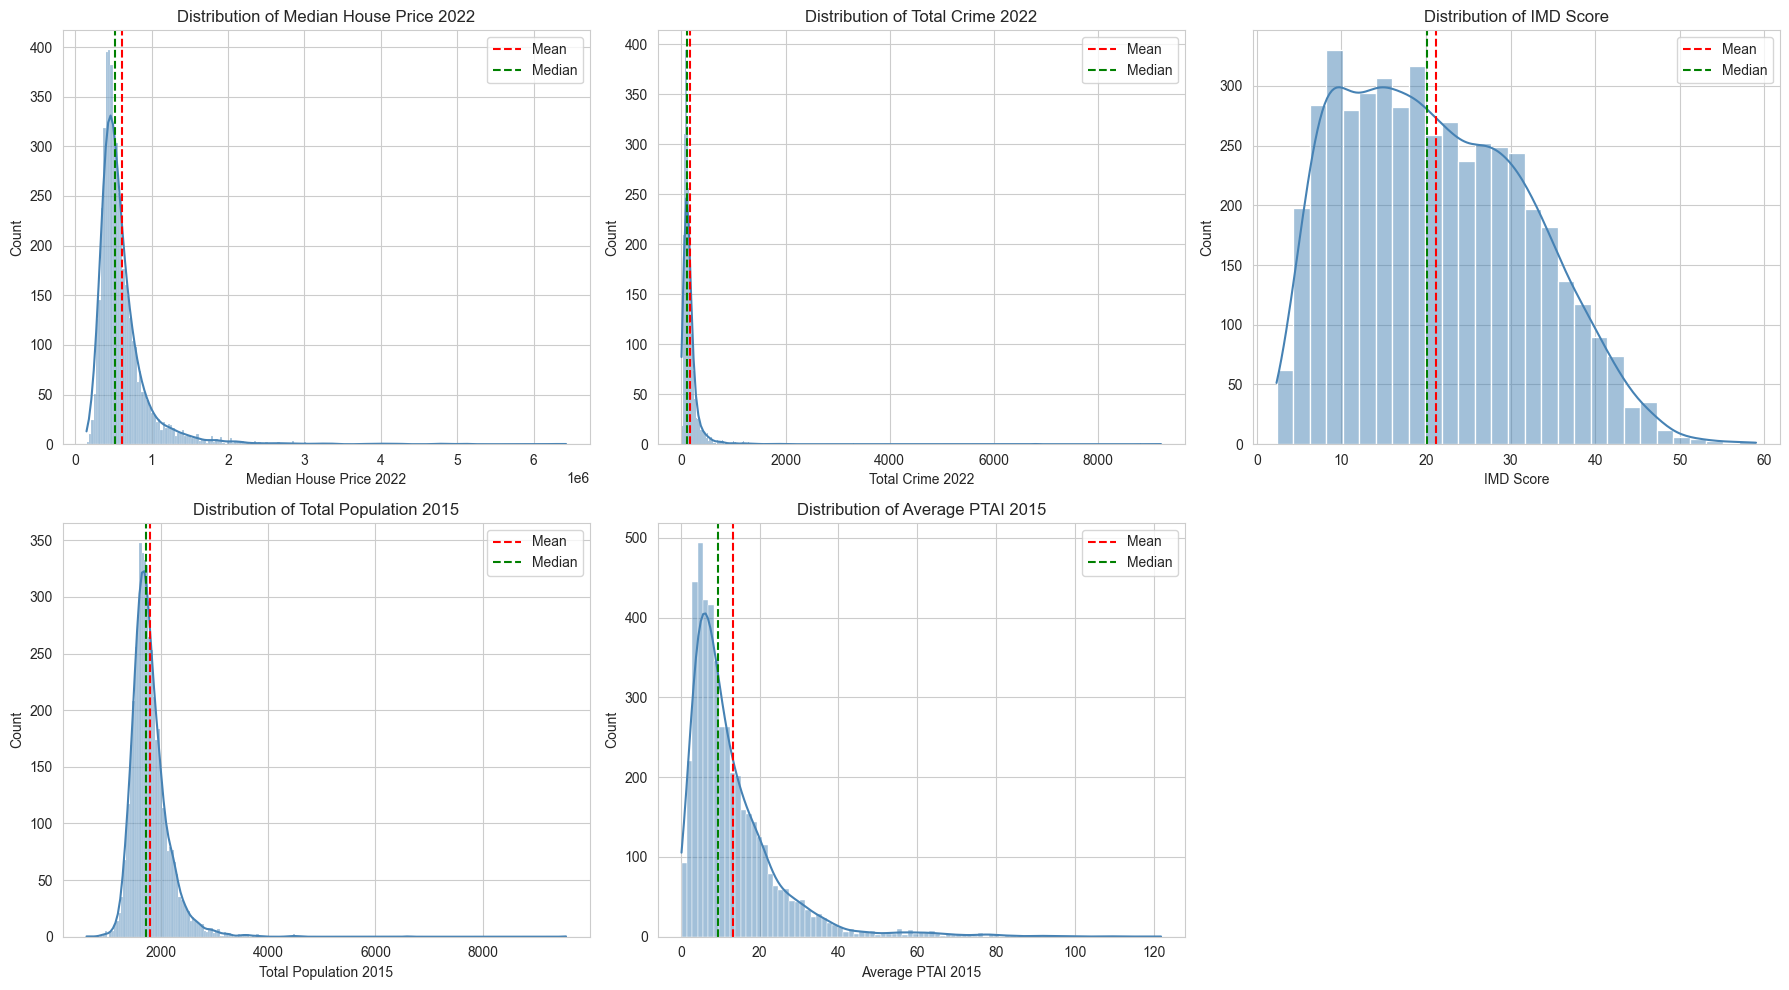

In [47]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', label='Mean')
    axes[i].axvline(df[col].median(), color='green', linestyle='--', label='Median')
    axes[i].legend()

axes[-1].axis('off')
plt.tight_layout()
plt.show()

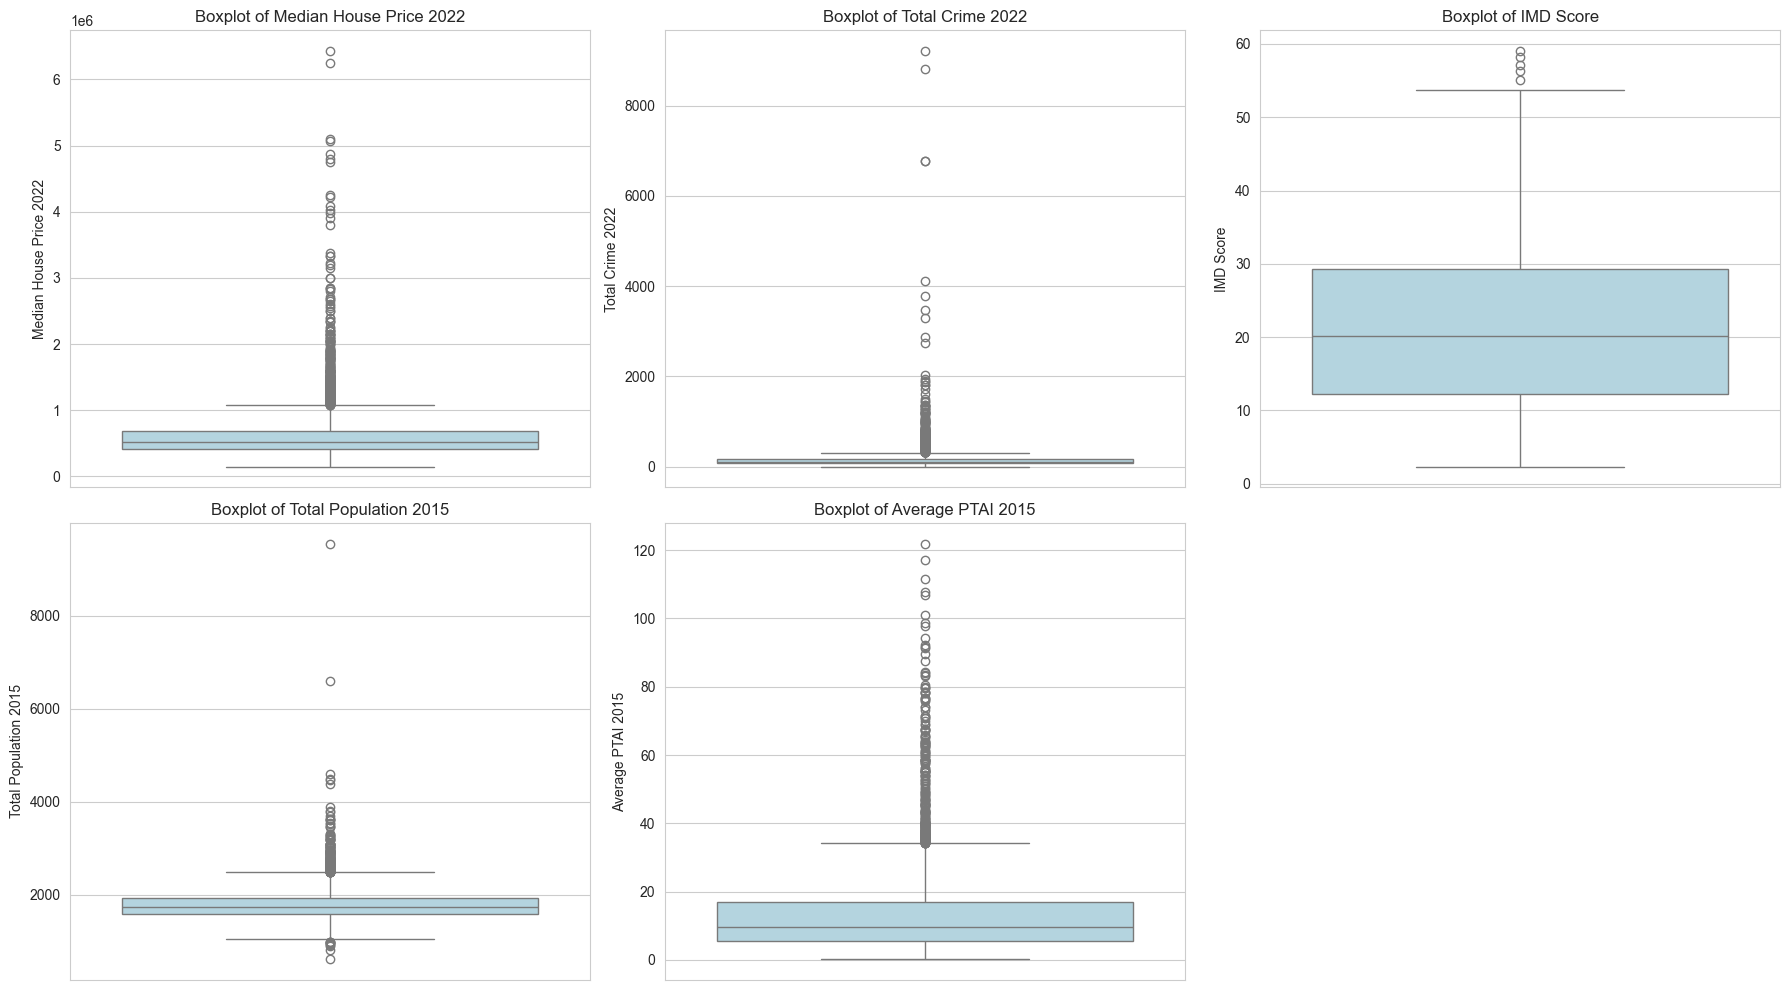

In [48]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='lightblue')
    axes[i].set_title(f'Boxplot of {col}')

axes[-1].axis('off')
plt.tight_layout()
plt.show()

In [49]:
skew_table = pd.DataFrame({'Skewness': df[numeric_cols].skew()})
skew_table

,Skewness
Median House Price 2022,5.240376
Total Crime 2022,17.523951
IMD Score,0.375036
Total Population 2015,3.885085
Average PTAI 2015,2.922126


### Borough-level summary

In [50]:
borough_summary = df.groupby('Local authority name')[numeric_cols].mean().sort_values(
    'Median House Price 2022', ascending=False)
borough_summary

,Median House Price 2022,Total Crime 2022,IMD Score,Total Population 2015,Average PTAI 2015
Local authority name,,,,,
Kensington and Chelsea,1.577159e+06,201.418367,20.789255,1551.316327,25.303408
Westminster,1.273461e+06,586.971774,19.902419,1860.758065,37.225616
Camden,8.730572e+05,255.923387,18.996629,1846.927419,27.149696
Richmond upon Thames,8.607894e+05,96.626087,9.423122,1688.034783,7.664744
Hammersmith and Fulham,8.352859e+05,170.712963,21.417250,1612.250000,18.572914
City of London,7.781250e+05,4.000000,14.712500,882.000000,86.542850
Wandsworth,7.633621e+05,129.977401,16.258949,1780.740113,17.158287
Barnet,7.455284e+05,124.360577,15.627288,1797.341346,8.048187
Islington,7.003639e+05,216.590164,27.845172,1847.434426,26.003469


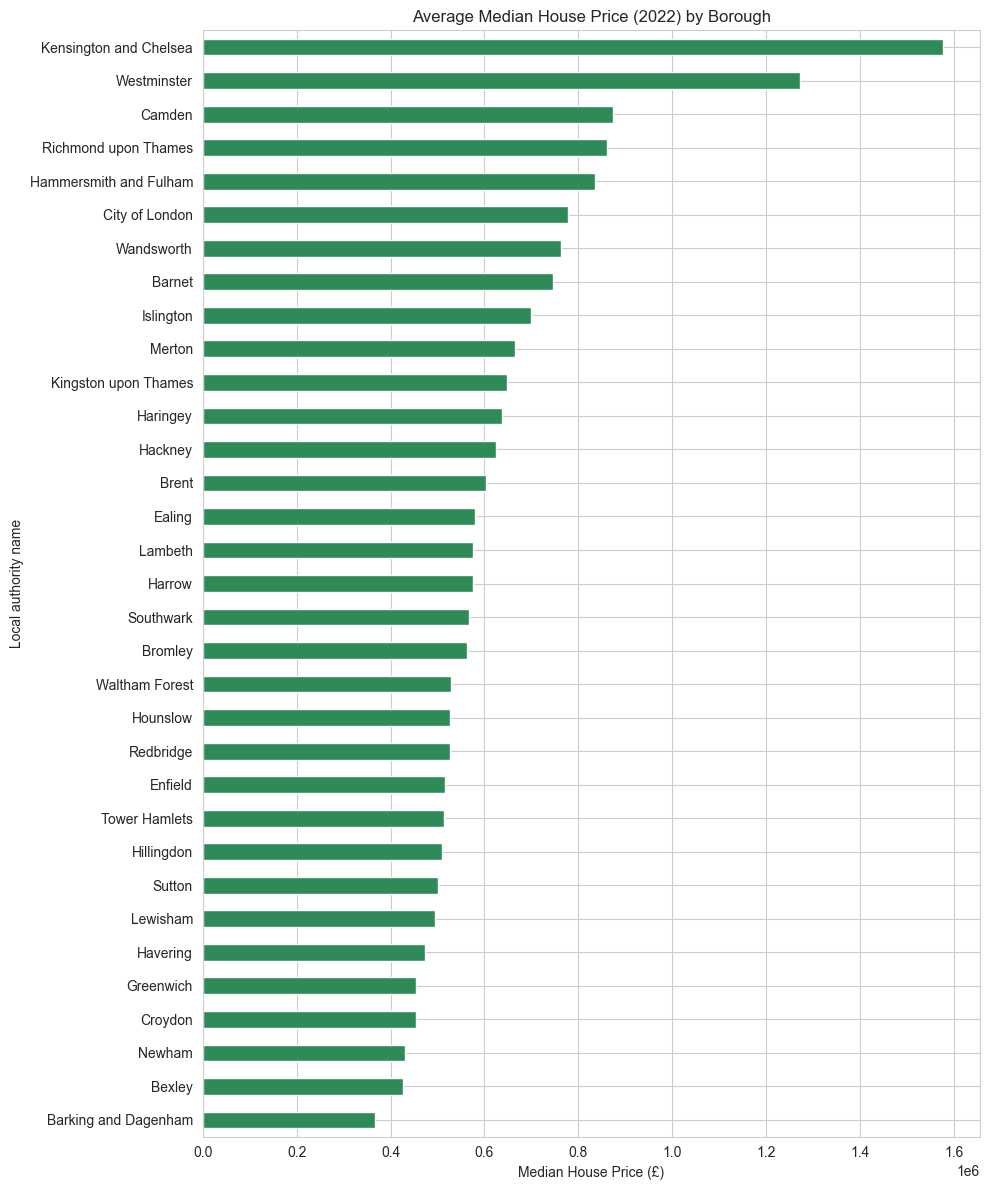

In [15]:
fig, ax = plt.subplots(figsize=(10, 12))
borough_summary['Median House Price 2022'].sort_values().plot(kind='barh', ax=ax, color='seagreen')
ax.set_title('Average Median House Price (2022) by Borough')
ax.set_xlabel('Median House Price (£)')
plt.tight_layout()
plt.show()

### Bivariate Analysis

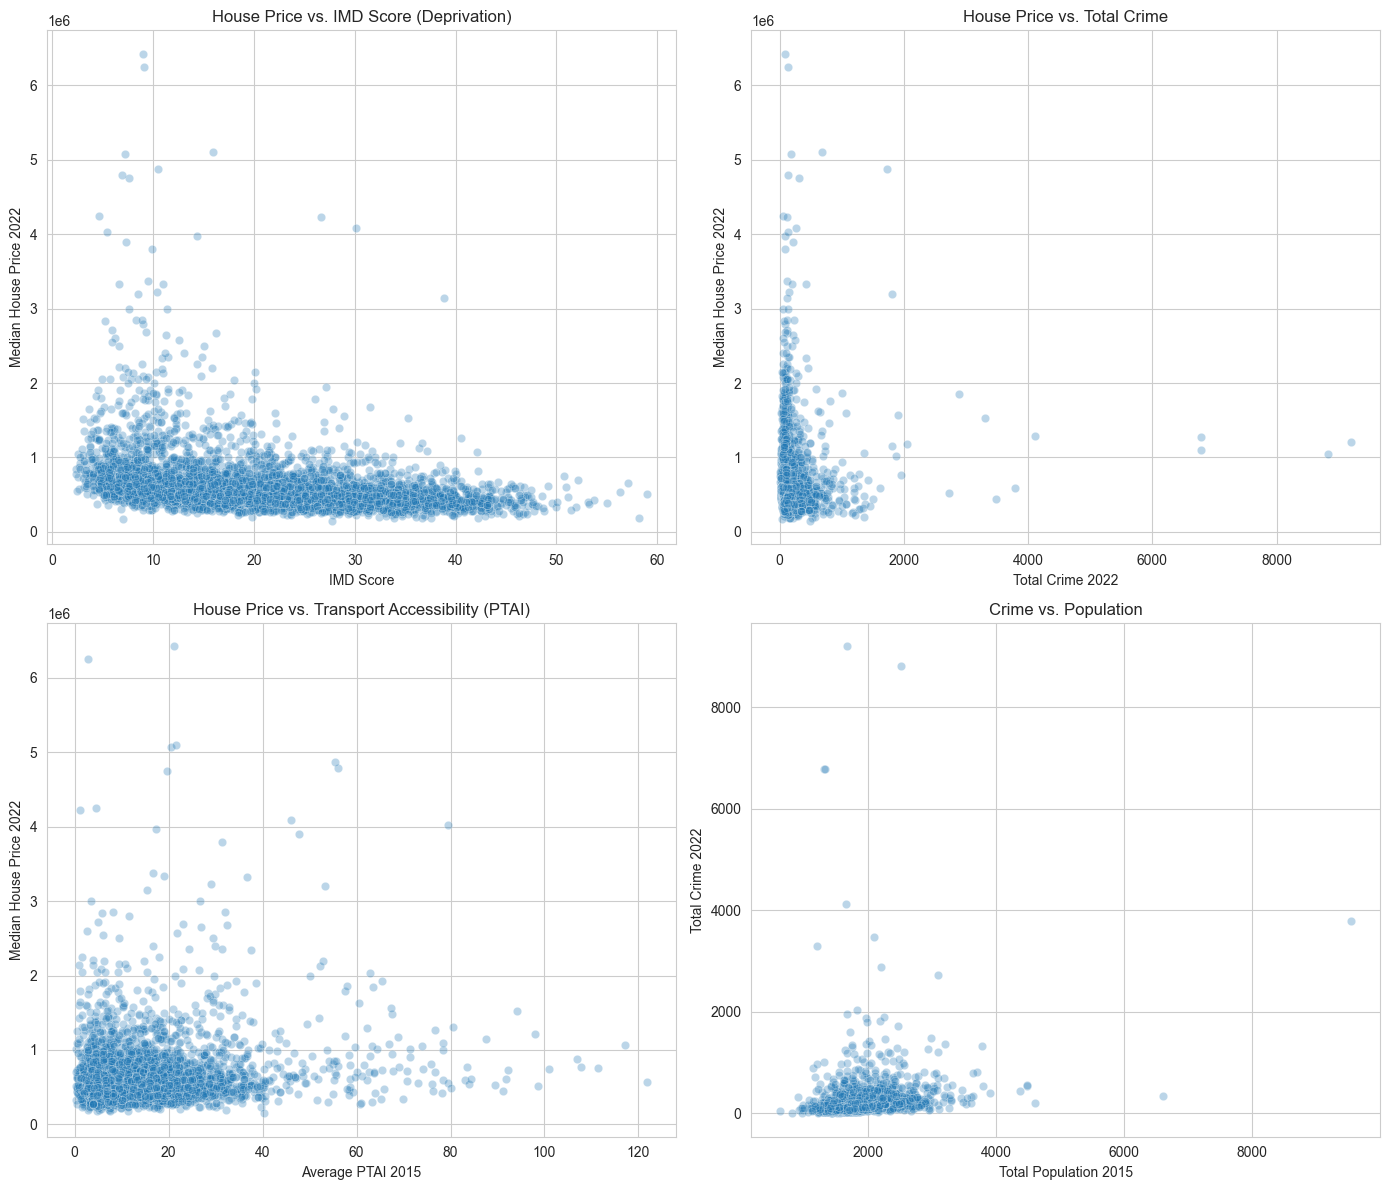

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

sns.scatterplot(data=df, x='IMD Score', y='Median House Price 2022', alpha=0.3, ax=axes[0,0])
axes[0,0].set_title('House Price vs. IMD Score (Deprivation)')

sns.scatterplot(data=df, x='Total Crime 2022', y='Median House Price 2022', alpha=0.3, ax=axes[0,1])
axes[0,1].set_title('House Price vs. Total Crime')

sns.scatterplot(data=df, x='Average PTAI 2015', y='Median House Price 2022', alpha=0.3, ax=axes[1,0])
axes[1,0].set_title('House Price vs. Transport Accessibility (PTAI)')

sns.scatterplot(data=df, x='Total Population 2015', y='Total Crime 2022', alpha=0.3, ax=axes[1,1])
axes[1,1].set_title('Crime vs. Population')

plt.tight_layout()
plt.show()

/var/folders/rl/9g7r04s17kq73vf2h8r9br0h0000gn/T/ipykernel_27171/3812764726.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=65)


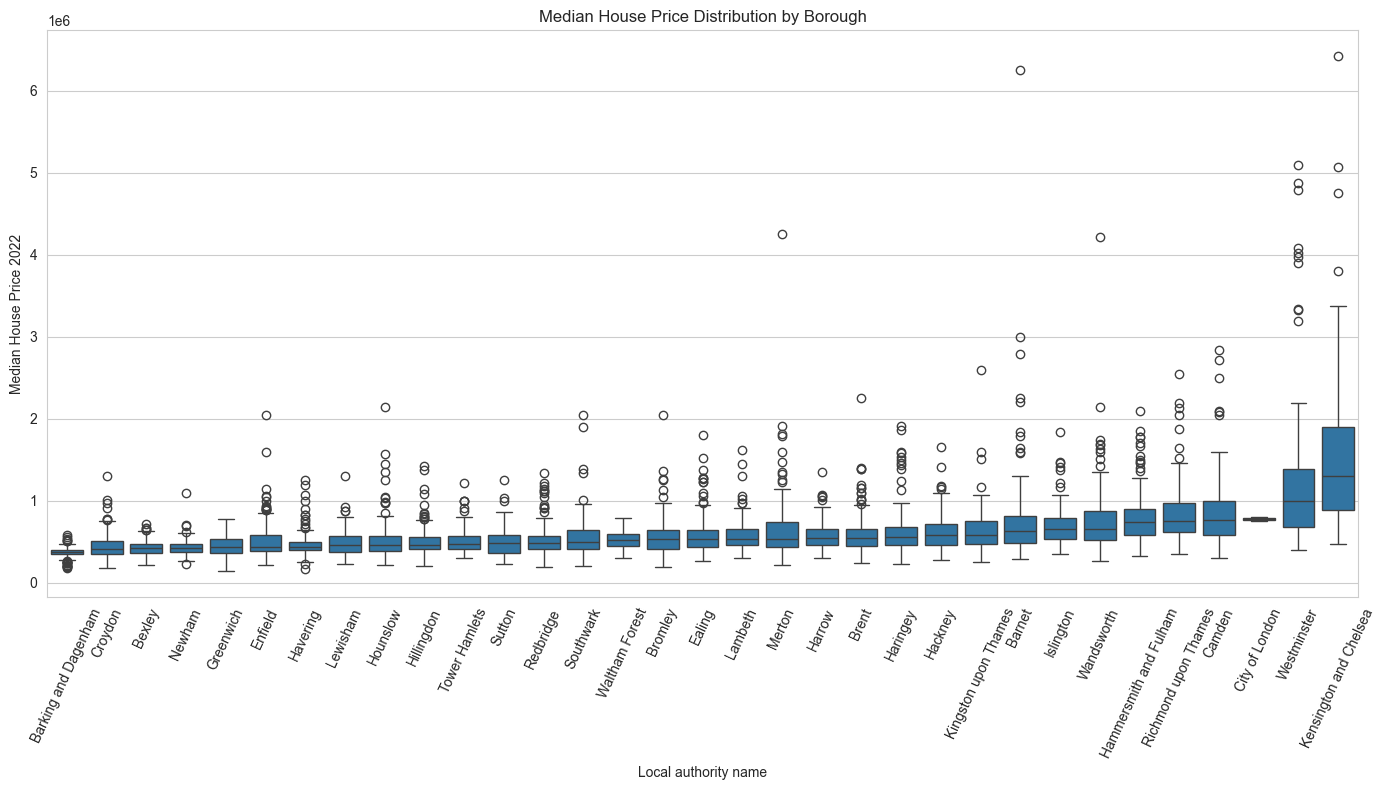

In [25]:
fig, ax = plt.subplots(figsize=(14, 8))
order = df.groupby('Local authority name')['Median House Price 2022'].median().sort_values().index
sns.boxplot(data=df, x='Local authority name', y='Median House Price 2022', order=order, ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=65)
ax.set_title('Median House Price Distribution by Borough')
plt.tight_layout()
plt.show()

---
## Task 2

**Hypothesis:** Areas with higher deprivation have significantly lower median house prices than areas with lower deprivation.

- Null Hypothesis: there is no difference in mean house price between high- and low-deprivation areas.
- Alternative hypothesis: mean house price differs between high- and low-deprivation areas.

Welch's t-test formula was used because the two groups have unequal variances instead of t-test as distribution is almost same as STD DEV.

In [51]:
median_imd = df['IMD Score'].median()
df['IMD_Group'] = np.where(df['IMD Score'] > median_imd, 'High Deprivation', 'Low Deprivation')

high_dep = df.loc[df['IMD_Group'] == 'High Deprivation', 'Median House Price 2022']
low_dep = df.loc[df['IMD_Group'] == 'Low Deprivation', 'Median House Price 2022']

high_dep
low_dep

0       205000
29      392500
30      430000
31      450000
59      585000
         ...  
4744    389975
4746    463500
4749    272500
4751    282500
4752    279437
Name: Median House Price 2022, Length: 2379, dtype: int64

In [52]:
se_diff = np.sqrt(var1/n1 + var2/n2)
diff = mean1 - mean2
t_stat = diff / se_diff

print(f"Difference in means: £{diff:,.0f}")
print(f"Standard error of the difference: £{se_diff:,.2f}")
print(f"t-statistic: {t_stat:.3f}")

critical_value = 1.96
print(f"\nCritical value (95% confidence): +/-{critical_value}")

if abs(t_stat) > critical_value:
    print(f"|t| = {abs(t_stat):.3f} > {critical_value} -> reject H0: the difference is statistically significant.")
else:
    print(f"|t| = {abs(t_stat):.3f} <= {critical_value} -> fail to reject H0: no significant difference detected.")

Difference in means: £-236,930
Standard error of the difference: £10,966.12
t-statistic: -21.606

Critical value (95% confidence): +/-1.96
|t| = 21.606 > 1.96 -> reject H0: the difference is statistically significant.


In [46]:

ci_low = diff - critical_value * se_diff
ci_high = diff + critical_value * se_diff

print(f"95% CI for the difference in means: (£{ci_low:,.0f}, £{ci_high:,.0f})")
print("(This interval does not contain 0, which is consistent with a statistically significant difference.)"
      if ci_low > 0 or ci_high < 0 else
      "(This interval contains 0, consistent with no statistically significant difference.)")

95% CI for the difference in means: (£-258,424, £-215,437)
(This interval does not contain 0, which is consistent with a statistically significant difference.)


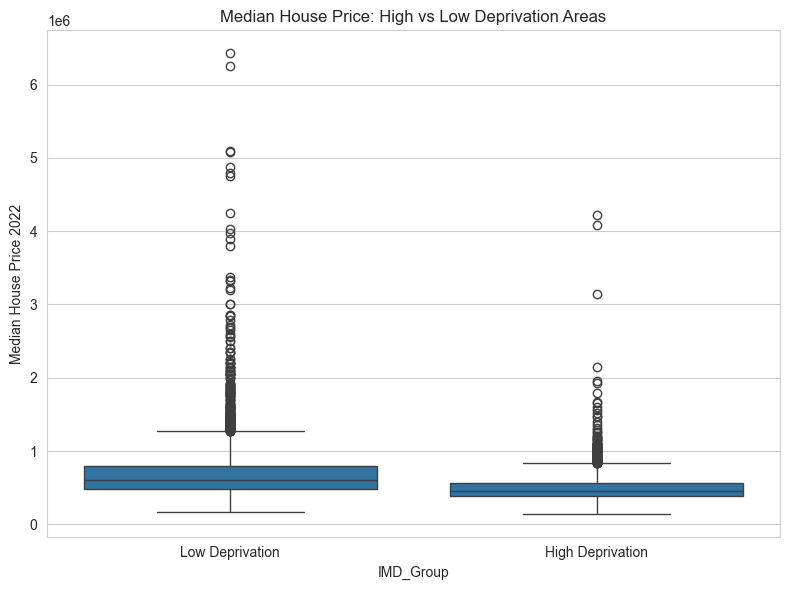

In [34]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(data=df, x='IMD_Group', y='Median House Price 2022')
ax.set_title('Median House Price: High vs Low Deprivation Areas')
plt.tight_layout()
plt.show()

---
## Task 3

### Correlation

In [35]:
corr_matrix = df[numeric_cols].corr(method='pearson')
corr_matrix

,Median House Price 2022,Total Crime 2022,IMD Score,Total Population 2015,Average PTAI 2015
Median House Price 2022,1.000000,0.045130,-0.344616,-0.153423,0.181191
Total Crime 2022,0.045130,1.000000,0.148946,0.242790,0.418324
IMD Score,-0.344616,0.148946,1.000000,0.152203,0.154609
Total Population 2015,-0.153423,0.242790,0.152203,1.000000,0.133782
Average PTAI 2015,0.181191,0.418324,0.154609,0.133782,1.000000


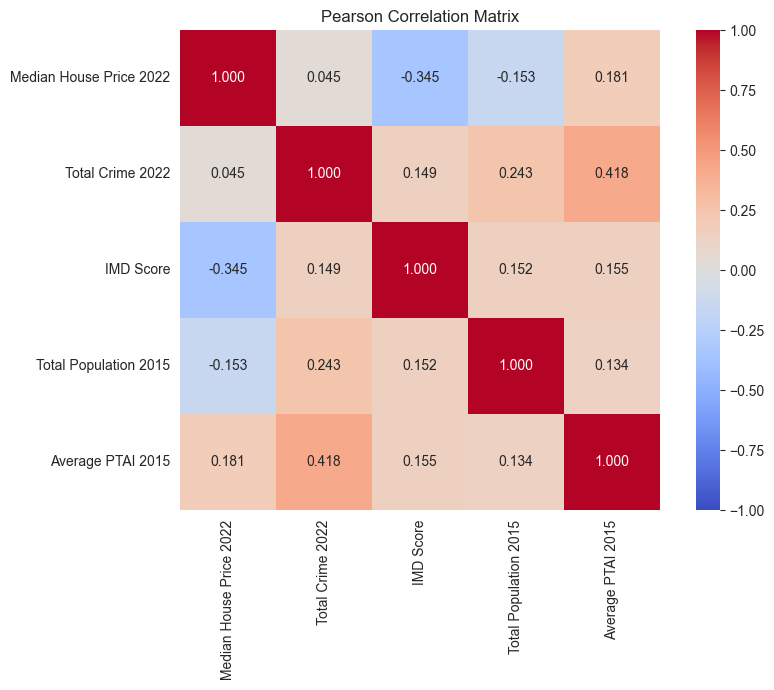

In [36]:
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            vmin=-1, vmax=1, ax=ax, square=True)
ax.set_title('Pearson Correlation Matrix')
plt.tight_layout()
plt.show()

### Regression Analysis

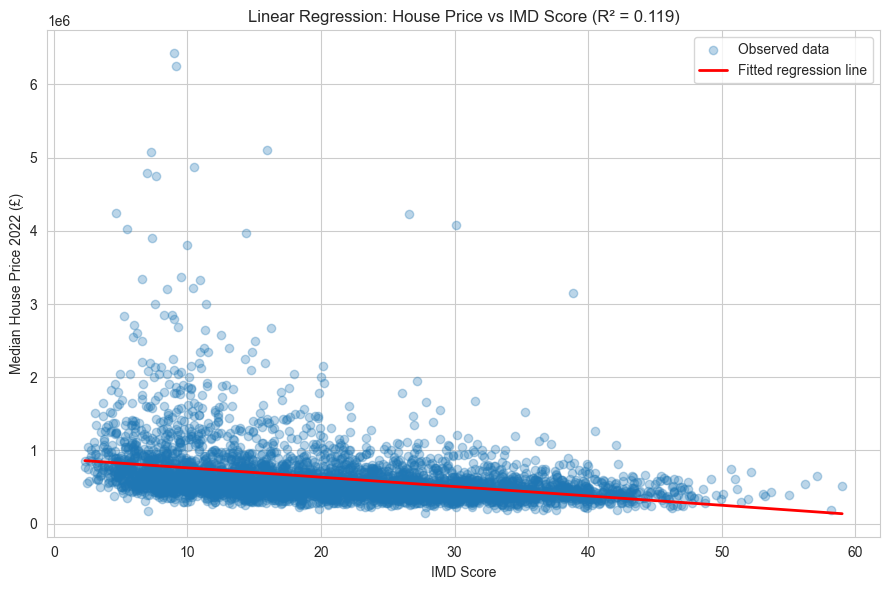

In [40]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(x, y, alpha=0.3, label='Observed data')

x_line = np.linspace(x.min(), x.max(), 100)
y_line = intercept + slope * x_line
ax.plot(x_line, y_line, color='red', linewidth=2, label='Fitted regression line')

ax.set_xlabel('IMD Score')
ax.set_ylabel('Median House Price 2022 (£)')
ax.set_title(f'Linear Regression: House Price vs IMD Score (R² = {r_squared:.3f})')
ax.legend()
plt.tight_layout()
plt.show()

---
## Task 4

See report.